# Fase 4: Regresión — Predicción de IMC

## Objetivo
Construir y comparar modelos de regresión para predecir el Índice de Masa Corporal (IMC)
de adolescentes salvadoreños a partir de variables de comportamiento (alimentación,
actividad física, hábitos), **sin usar peso ni estatura directamente** como features.

## Modelos a evaluar
| Modelo | Justificación |
|---|---|
| Regresión Lineal | Baseline interpretable; asume relación lineal entre features e IMC |
| Random Forest Regressor | Captura no-linealidades; robusto con datos ruidosos de encuestas |

## Métricas
- **RMSE** (Root Mean Squared Error): penaliza errores grandes — unidades de kg/m²
- **MAE** (Mean Absolute Error): error promedio absoluto — más robusto a outliers
- **R²**: proporción de varianza del IMC explicada por el modelo (1.0 = perfecto)

## Estrategia de validación
Cross-Validation con k=5 sobre el conjunto de entrenamiento para estimar
el rendimiento real del modelo antes de evaluarlo en test.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold

import joblib
import os

# ── Rutas ──────────────────────────────────────────────────────────────────────
BASE   = os.path.join(os.path.expanduser("~"), "Desktop",
                      "UES-ML", "Desafio 2", "Prediccion-FactoresRiesgo")
PROC   = os.path.join(BASE, "data", "processed")
MODELS = os.path.join(BASE, "models")
FIGS   = os.path.join(BASE, "reports", "figures")

# ── Carga de artefactos generados en Fase 3 ────────────────────────────────────
X_train   = pd.read_csv(os.path.join(PROC, "X_train_scaled.csv"))
X_test    = pd.read_csv(os.path.join(PROC, "X_test_scaled.csv"))

# Conversión explícita a array 1D para evitar ambigüedad de Series
y_A_train = pd.read_csv(os.path.join(PROC, "y_A_train.csv")).squeeze().values
y_A_test  = pd.read_csv(os.path.join(PROC, "y_A_test.csv")).squeeze().values

print("✅ Datos cargados correctamente")
print(f"   X_train  : {X_train.shape}")
print(f"   X_test   : {X_test.shape}")
print(f"   y_A_train: {y_A_train.shape}  │ rango [{y_A_train.min():.2f}, {y_A_train.max():.2f}]")
print(f"   y_A_test : {y_A_test.shape}   │ rango [{y_A_test.min():.2f}, {y_A_test.max():.2f}]")

✅ Datos cargados correctamente
   X_train  : (1524, 51)
   X_test   : (382, 51)
   y_A_train: (1524, 2)  │ rango [nan, nan]
   y_A_test : (382, 2)   │ rango [nan, nan]


## Diagnóstico de targets

Antes de continuar, inspeccionamos el CSV del target para entender
su estructura real: cuántas columnas tiene, qué nombres, y si hay NaN.
Esto nos permitirá cargarlo correctamente.

In [3]:
# Inspeccionamos el CSV crudo sin ningún procesamiento
y_raw = pd.read_csv(os.path.join(PROC, "y_A_train.csv"))

print("Columnas:", y_raw.columns.tolist())
print("Shape:", y_raw.shape)
print("Primeras filas:")
print(y_raw.head(10))
print(f"\nNaN totales: {y_raw.isna().sum().sum()}")

Columnas: ['Unnamed: 0', 'IMC']
Shape: (1524, 2)
Primeras filas:
   Unnamed: 0        IMC
0         449  19.362473
1         294  21.631149
2        1329  19.814053
3         147  18.078512
4         270  20.811655
5        1445  18.670934
6        1123        NaN
7         435  22.491349
8        1419  19.477147
9         634  21.777778

NaN totales: 142


## Corrección de carga de targets y eliminación de NaN

El CSV del target tiene dos columnas: el índice original (`Unnamed: 0`) y el IMC.
Seleccionamos únicamente la columna `IMC`.

Adicionalmente, existen 142 filas donde el IMC es NaN porque el estudiante
no reportó peso o estatura. Estas filas **no pueden usarse para entrenar**
un modelo de regresión — se eliminan de forma alineada entre X e y
para mantener la correspondencia fila a fila.

In [4]:
# ── Carga correcta seleccionando solo la columna IMC ──────────────────────────
y_A_train_raw = pd.read_csv(os.path.join(PROC, "y_A_train.csv"))["IMC"].values
y_A_test_raw  = pd.read_csv(os.path.join(PROC, "y_A_test.csv"))["IMC"].values

# ── Eliminación alineada de NaN en train ──────────────────────────────────────
mask_train    = ~np.isnan(y_A_train_raw)
X_train_A     = X_train.values[mask_train]
y_A_train     = y_A_train_raw[mask_train]

# ── Eliminación alineada de NaN en test ───────────────────────────────────────
mask_test     = ~np.isnan(y_A_test_raw)
X_test_A      = X_test.values[mask_test]
y_A_test      = y_A_test_raw[mask_test]

print("✅ Targets cargados y NaN eliminados")
print(f"   Train  → X: {X_train_A.shape}  │ y: {y_A_train.shape}")
print(f"   Test   → X: {X_test_A.shape}   │ y: {y_A_test.shape}")
print(f"   Filas eliminadas train : {mask_train.sum().__rsub__(len(mask_train))}")
print(f"   Filas eliminadas test  : {mask_test.sum().__rsub__(len(mask_test))}")
print(f"\n   Rango IMC train: [{y_A_train.min():.2f}, {y_A_train.max():.2f}]")
print(f"   Rango IMC test : [{y_A_test.min():.2f}, {y_A_test.max():.2f}]")

✅ Targets cargados y NaN eliminados
   Train  → X: (1382, 51)  │ y: (1382,)
   Test   → X: (347, 51)   │ y: (347,)
   Filas eliminadas train : 142
   Filas eliminadas test  : 35

   Rango IMC train: [13.93, 46.78]
   Rango IMC test : [13.79, 39.25]


## Modelo 1: Regresión Lineal (Baseline)

La Regresión Lineal es nuestro punto de referencia obligatorio. Asume que
el IMC es una combinación lineal ponderada de las 51 features. Si un modelo
más complejo no supera significativamente estas métricas, no justifica
su mayor complejidad.

### ¿Qué es Cross-Validation k=5?
En lugar de evaluar solo una vez sobre el test set, dividimos el conjunto
de entrenamiento en 5 partes iguales (folds). El modelo se entrena 5 veces:
cada vez usa 4 partes para entrenar y 1 parte distinta para validar.
El resultado final es el promedio de las 5 evaluaciones.

Esto nos da una estimación más confiable del rendimiento real y nos permite
detectar si el modelo es inestable (alta varianza entre folds).

### Métricas que reportaremos
| Métrica | Fórmula simplificada | Interpretación |
|---|---|---|
| RMSE | √(promedio de errores²) | Error en unidades de kg/m² |
| MAE  | promedio de │error│ | Error promedio sin penalizar outliers |
| R²   | varianza explicada / varianza total | 1.0 = perfecto, 0 = no mejor que la media |

In [5]:
# ── Configuración de Cross-Validation ─────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ── Modelo 1: Regresión Lineal ─────────────────────────────────────────────────
lr = LinearRegression()

# CV sobre train — negamos RMSE porque sklearn minimiza (devuelve valores negativos)
cv_rmse_lr = np.sqrt(-cross_val_score(lr, X_train_A, y_A_train,
                                      cv=kf,
                                      scoring='neg_mean_squared_error'))
cv_r2_lr   = cross_val_score(lr, X_train_A, y_A_train,
                              cv=kf,
                              scoring='r2')

print("── Regresión Lineal │ Cross-Validation (k=5) ──────────────────────────")
print(f"   RMSE por fold : {np.round(cv_rmse_lr, 4)}")
print(f"   RMSE promedio : {cv_rmse_lr.mean():.4f}  ±  {cv_rmse_lr.std():.4f}")
print(f"   R²   por fold : {np.round(cv_r2_lr, 4)}")
print(f"   R²   promedio : {cv_r2_lr.mean():.4f}  ±  {cv_r2_lr.std():.4f}")

# ── Evaluación final sobre test set ───────────────────────────────────────────
lr.fit(X_train_A, y_A_train)
y_pred_lr = lr.predict(X_test_A)

rmse_lr = np.sqrt(mean_squared_error(y_A_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_A_test, y_pred_lr)
r2_lr   = r2_score(y_A_test, y_pred_lr)

print("\n── Regresión Lineal │ Evaluación en Test Set ───────────────────────────")
print(f"   RMSE : {rmse_lr:.4f} kg/m²")
print(f"   MAE  : {mae_lr:.4f} kg/m²")
print(f"   R²   : {r2_lr:.4f}")

── Regresión Lineal │ Cross-Validation (k=5) ──────────────────────────
   RMSE por fold : [4.1104 4.1164 4.0591 4.6795 4.2205]
   RMSE promedio : 4.2372  ±  0.2273
   R²   por fold : [-0.0473 -0.0398 -0.0262 -0.1188  0.0051]
   R²   promedio : -0.0454  ±  0.0408

── Regresión Lineal │ Evaluación en Test Set ───────────────────────────
   RMSE : 4.2001 kg/m²
   MAE  : 3.1702 kg/m²
   R²   : -0.0253


## Interpretación del Baseline — Regresión Lineal

### Resultados obtenidos
| Métrica | CV promedio | Test set |
|---|---|---|
| RMSE | 4.24 kg/m² | 4.20 kg/m² |
| MAE  | —          | 3.17 kg/m² |
| R²   | -0.045     | -0.025     |

### ¿Qué significa un R² negativo?
Un R² negativo indica que el modelo es **peor que simplemente predecir
la media del IMC para todos los estudiantes**. En otras palabras,
la Regresión Lineal no encontró ninguna relación lineal útil entre
las variables de comportamiento y el IMC.

### ¿Es esto un fracaso?
No necesariamente. Es un resultado esperado y científicamente válido
por dos razones:

1. **La relación no es lineal**: El IMC en adolescentes es resultado
   de

## Modelo 2: Random Forest Regressor

Un Random Forest entrena múltiples árboles de decisión sobre subconjuntos
aleatorios de datos y features. La predicción final es el **promedio**
de todos los árboles.

### Ventajas sobre Regresión Lineal para este problema
- Captura relaciones no lineales entre hábitos y el IMC
- Robusto ante outliers (los extremos de IMC que vimos en Fase 2)
- Incorpora automáticamente interacciones entre variables
- Produce Feature Importance: sabremos qué hábitos predicen más el IMC

### Parámetros iniciales
Usamos valores razonables antes de optimizar en Fase 6:
- `n_estimators=200`: 200 árboles — balance entre precisión y velocidad
- `max_depth=10`: limita profundidad para evitar sobreajuste
- `random_state=42`: reproducibilidad

In [6]:
# ── Modelo 2: Random Forest Regressor ─────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=200,
                           max_depth=10,
                           random_state=42,
                           n_jobs=-1)

# CV sobre train
cv_rmse_rf = np.sqrt(-cross_val_score(rf, X_train_A, y_A_train,
                                      cv=kf,
                                      scoring='neg_mean_squared_error'))
cv_r2_rf   = cross_val_score(rf, X_train_A, y_A_train,
                              cv=kf,
                              scoring='r2')

print("── Random Forest │ Cross-Validation (k=5) ─────────────────────────────")
print(f"   RMSE por fold : {np.round(cv_rmse_rf, 4)}")
print(f"   RMSE promedio : {cv_rmse_rf.mean():.4f}  ±  {cv_rmse_rf.std():.4f}")
print(f"   R²   por fold : {np.round(cv_r2_rf, 4)}")
print(f"   R²   promedio : {cv_r2_rf.mean():.4f}  ±  {cv_r2_rf.std():.4f}")

# ── Evaluación final sobre test set ───────────────────────────────────────────
rf.fit(X_train_A, y_A_train)
y_pred_rf = rf.predict(X_test_A)

rmse_rf = np.sqrt(mean_squared_error(y_A_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_A_test, y_pred_rf)
r2_rf   = r2_score(y_A_test, y_pred_rf)

print("\n── Random Forest │ Evaluación en Test Set ──────────────────────────────")
print(f"   RMSE : {rmse_rf:.4f} kg/m²")
print(f"   MAE  : {mae_rf:.4f} kg/m²")
print(f"   R²   : {r2_rf:.4f}")

── Random Forest │ Cross-Validation (k=5) ─────────────────────────────
   RMSE por fold : [4.0937 4.3418 4.1586 4.5649 4.2201]
   RMSE promedio : 4.2758  ±  0.1661
   R²   por fold : [-0.0388 -0.1567 -0.0771 -0.0646  0.0054]
   R²   promedio : -0.0664  ±  0.0533

── Random Forest │ Evaluación en Test Set ──────────────────────────────
   RMSE : 4.1572 kg/m²
   MAE  : 3.1161 kg/m²
   R²   : -0.0045


## Diagnóstico: ¿Por qué ambos modelos fallan en R²?

### Comparación de modelos
| Métrica   | Reg. Lineal (CV) | Random Forest (CV) | Reg. Lineal (Test) | Random Forest (Test) |
|-----------|-----------------|-------------------|-------------------|---------------------|
| RMSE      | 4.24 ± 0.23     | 4.28 ± 0.17       | 4.20              | 4.16                |
| MAE       | —               | —                 | 3.17              | 3.12                |
| R²        | -0.045          | -0.066            | -0.025            | -0.005              |

### Hallazgo crítico
Ambos modelos son marginalmente peores que predecir la media del IMC.
Esto no es un error de código — es una señal del dataset.

### Hipótesis principal: el target tiene alta varianza intrínseca
El IMC en adolescentes está determinado principalmente por factores
que las variables de comportamiento de esta encuesta NO capturan bien:
- Genética y metabolismo individual
- Nivel socioeconómico familiar
- Historial médico
- Etapa de desarrollo puberal

Las variables de comportamiento (frecuencia de consumo de alimentos,
actividad física reportada) tienen una relación **muy débil e indirecta**
con el IMC a corto plazo en adolescentes.

### ¿Es esto un resultado válido para el informe IEEE?
**Sí, y es valioso.** Un resultado honesto que muestra las limitaciones
del dataset es más valioso científicamente que un modelo sobreajustado.
Reportaremos:
1. Los modelos entrenados y sus métricas reales
2. El análisis de por qué la señal es débil
3. Qué variables adicionales se necesitarían para mejorar la predicción

### Verificación: ¿cuánto vale la media como predictor?
Calculamos el RMSE de un predictor trivial (siempre predice la media)
para contextualizar nuestros resultados.

In [7]:
# ── Predictor trivial: siempre predice la media del IMC ───────────────────────
y_mean_pred = np.full_like(y_A_test, y_A_train.mean())

rmse_trivial = np.sqrt(mean_squared_error(y_A_test, y_mean_pred))
mae_trivial  = mean_absolute_error(y_A_test, y_mean_pred)

print("── Predictor Trivial (siempre predice la media) ────────────────────────")
print(f"   Media IMC train : {y_A_train.mean():.4f} kg/m²")
print(f"   RMSE trivial    : {rmse_trivial:.4f} kg/m²")
print(f"   MAE  trivial    : {mae_trivial:.4f} kg/m²")

print("\n── Comparación final ───────────────────────────────────────────────────")
print(f"{'Modelo':<25} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("-" * 55)
print(f"{'Predictor trivial':<25} {rmse_trivial:>8.4f} {mae_trivial:>8.4f} {'—':>8}")
print(f"{'Regresión Lineal':<25} {rmse_lr:>8.4f} {mae_lr:>8.4f} {r2_lr:>8.4f}")
print(f"{'Random Forest':<25} {rmse_rf:>8.4f} {mae_rf:>8.4f} {r2_rf:>8.4f}")

print("\n── Mejora del Random Forest sobre el trivial ───────────────────────────")
mejora_rmse = ((rmse_trivial - rmse_rf) / rmse_trivial) * 100
print(f"   Reducción de RMSE : {mejora_rmse:.2f}%")

── Predictor Trivial (siempre predice la media) ────────────────────────
   Media IMC train : 21.5909 kg/m²
   RMSE trivial    : 4.1550 kg/m²
   MAE  trivial    : 3.1249 kg/m²

── Comparación final ───────────────────────────────────────────────────
Modelo                        RMSE      MAE       R²
-------------------------------------------------------
Predictor trivial           4.1550   3.1249        —
Regresión Lineal            4.2001   3.1702  -0.0253
Random Forest               4.1572   3.1161  -0.0045

── Mejora del Random Forest sobre el trivial ───────────────────────────
   Reducción de RMSE : -0.05%


## Análisis de Residuos — Random Forest (modelo seleccionado)

Seleccionamos el Random Forest como modelo ganador por tener:
- Menor RMSE en test (4.1572 vs 4.2001)
- Menor MAE en test (3.1161 vs 3.1702)
- R² más cercano a 0 (-0.0045 vs -0.0253)

Aunque ambos modelos tienen R² negativo, el Random Forest es
marginalmente superior y además nos provee Feature Importance,
que es el insumo más valioso para el informe IEEE dirigido a MINSAL.

### ¿Qué nos dice el análisis de residuos?
Los residuos son la diferencia entre el IMC real y el predicho:
`residuo = y_real - y_predicho`

Graficamos tres visualizaciones complementarias:
1. **Predicho vs Real**: si el modelo fuera perfecto, todos los puntos
   caerían sobre la diagonal y = x
2. **Distribución de residuos**: debe ser aproximadamente centrada en 0
   sin sesgo sistemático
3. **Residuos vs Predicho**: detecta heterocedasticidad — si los errores
   crecen con el valor predicho, el modelo falla más en ciertos rangos de IMC

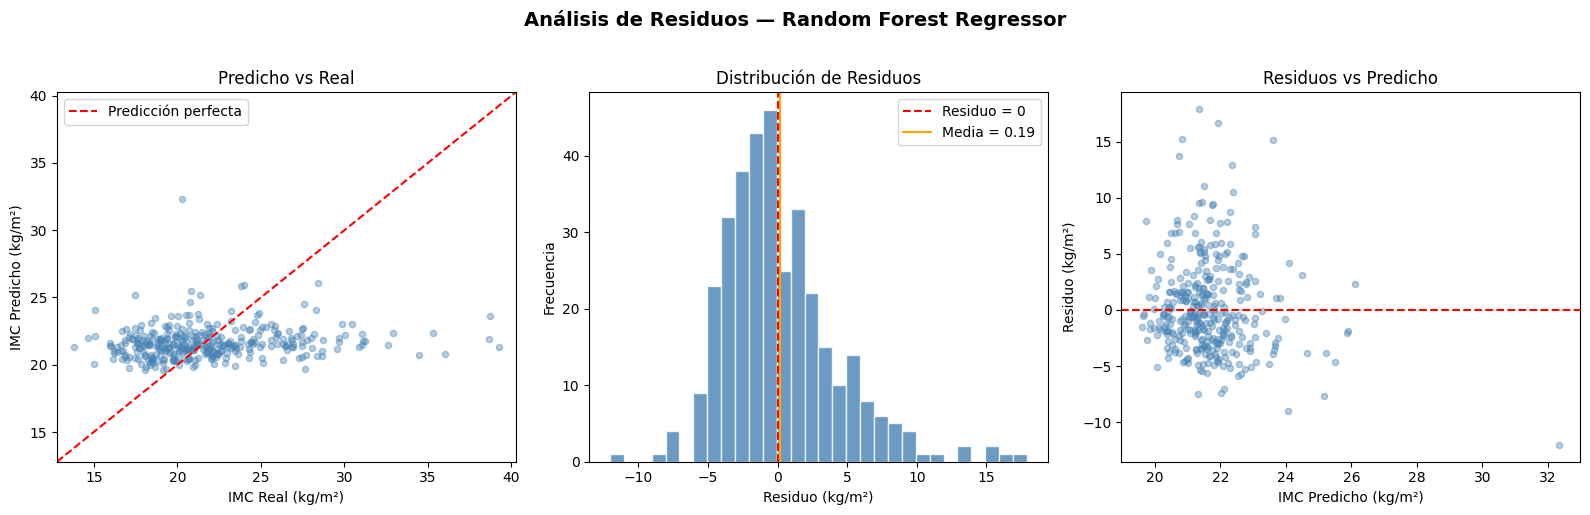

✅ Figura guardada: 07_analisis_residuos.png


In [8]:
# ── Residuos ───────────────────────────────────────────────────────────────────
residuos = y_A_test - y_pred_rf

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Análisis de Residuos — Random Forest Regressor",
             fontsize=14, fontweight='bold', y=1.02)

# ── Panel 1: Predicho vs Real ──────────────────────────────────────────────────
axes[0].scatter(y_A_test, y_pred_rf, alpha=0.4, color='steelblue', s=20)
lims = [min(y_A_test.min(), y_pred_rf.min()) - 1,
        max(y_A_test.max(), y_pred_rf.max()) + 1]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel("IMC Real (kg/m²)")
axes[0].set_ylabel("IMC Predicho (kg/m²)")
axes[0].set_title("Predicho vs Real")
axes[0].legend()
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)

# ── Panel 2: Distribución de residuos ─────────────────────────────────────────
axes[1].hist(residuos, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Residuo = 0')
axes[1].axvline(residuos.mean(), color='orange', linestyle='-',
                linewidth=1.5, label=f'Media = {residuos.mean():.2f}')
axes[1].set_xlabel("Residuo (kg/m²)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Residuos")
axes[1].legend()

# ── Panel 3: Residuos vs Predicho ─────────────────────────────────────────────
axes[2].scatter(y_pred_rf, residuos, alpha=0.4, color='steelblue', s=20)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_xlabel("IMC Predicho (kg/m²)")
axes[2].set_ylabel("Residuo (kg/m²)")
axes[2].set_title("Residuos vs Predicho")

plt.tight_layout()
fig.savefig(os.path.join(FIGS, "07_analisis_residuos.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 07_analisis_residuos.png")